In [21]:
import  tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical  

In [22]:
# Read the dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [23]:
X_train.shape

(60000, 28, 28)

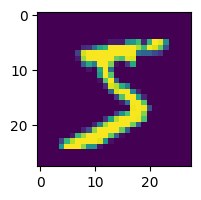

In [24]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])


In [25]:
import numpy as np

np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [26]:
y_train =  to_categorical(y_train, num_classes=10)
y_test =  to_categorical(y_test, num_classes=10)

In [27]:
model = Sequential([
    tf.keras.layers.Input(shape = X_train[0].shape),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [28]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)



Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.9607 - loss: 0.1628 - val_accuracy: 0.9488 - val_loss: 0.3144
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.9615 - loss: 0.1522 - val_accuracy: 0.9467 - val_loss: 0.3310
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 591us/step - accuracy: 0.9596 - loss: 0.1674 - val_accuracy: 0.9469 - val_loss: 0.3032
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 598us/step - accuracy: 0.9625 - loss: 0.1585 - val_accuracy: 0.9491 - val_loss: 0.3330
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step - accuracy: 0.9629 - loss: 0.1539 - val_accuracy: 0.9470 - val_loss: 0.3332
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 596us/step - accuracy: 0.9632 - loss: 0.1491 - val_accuracy: 0.9496 - val_loss: 0.3432
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - accuracy: 0.9645 - loss: 0.1471 - val_accuracy: 0.9487 - val_loss: 0.3684
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - accuracy: 

In [37]:
#save the model
model.save('keras_mnist_model.keras')

In [38]:
# load the model

keras_model = load_model('keras_mnist_model.keras')

/opt/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [39]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - accuracy: 0.9458 - loss: 1.2403


[1.240280270576477, 0.9458000063896179]

In [40]:
keras_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.9458 - loss: 1.2403


[1.240280270576477, 0.9458000063896179]